# **Experiment Notebook**



In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


Project name = Streaming Churn

Type = Classification

Experiment = 1

<hr>

## B. Experiment Description


experiment_hypothesis: Using Random Forest will improve the precision, recall and F1 Score of churners compared to the baseline model.

experiment_expectations: I expect the random forest model to be better at predicting churns, however, I\'m not sure if it will improve the overall score. That would be ideal, but for now the main concern is improving the churn = 1 predictions. It would be better to get more false churns than to miss any of them.

<hr>

## C. Data Understanding


### C.0 Import Packages

In [2]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Numpy for numerical computing and array operations
import numpy as np

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Seaborn for data visualization
import seaborn as sns

<hr>

### C.1   Load Datasets

In [3]:
# Load training set
# Do not change this code

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

In [4]:
# Load validation set
# Do not change this code

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

In [5]:
# Load testing set
# Do not change this code

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

<hr>

<hr>

## D. Feature Selection


feature_selection_executive_summary: The five features selected for experiment 1 of the churn prediction model are MonthlyCharges, TotalCharges, ViewingHoursPerWeek, AverageViewingDuration, and AccountAge.

> Rationale: These features were chosen based on their high Mutual Information scores and Random Forest importance, indicating strong predictive power for customer churn. This selection balances financial metrics with engagement indicators and customer tenure, providing a robust foundation for the churn prediction model.

In [6]:
#fill the feature list

features_list = ['MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']

> Results: Feature list is created with the five selected features.

<hr>

## E. Data Preparation

data_preparation_executive_summary: The data preparation process for this experiment was limited to the creation of feature datasets (X) containing only the five selected features: MonthlyCharges, TotalCharges, ViewingHoursPerWeek, AverageViewingDuration, and AccountAge. No additional transformations or preprocessing steps were applied at this stage, maintaining the original scale and distribution of these key features for the initial modeling phase. All features selected are numerical so there is no need for encoding.

> Rationale:  Creating X datasets with only the selected features ensures that the model focuses on the most predictive variables, potentially reducing noise and improving computational efficiency.

In [7]:
## Create new X dataset with selected features.

X_train = X_train[features_list]
X_val = X_val[features_list]
X_test = X_test[features_list]

In [8]:
X_train.head()

,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,AccountAge
0,16.928159,1709.744041,13.021656,13.723653,101
1,14.302743,414.779558,25.375116,97.527373,29
2,15.379799,1045.826317,24.573082,27.119952,68
3,17.637105,758.395526,25.497697,40.559519,43
4,8.351956,626.396703,36.759650,76.408875,75


> Results: The X datasets now only contain the 5 selected features.

<hr>

## F. Feature Engineering

data_preparation_executive_summary_2: At this stage of the experiment, I have decided against creating new features. By proceeding with only the selected features, I can better assess the fundamental predictive power of these core variables. It also allows for a clear comparison between the chosen Random Forest model and the benchmark model in experiment 0 as they will both use the same features. As I progress, the results from this model will inform decisions on whether and how to engineer new features in subsequent experiments.

<hr>

## G. Train Machine Learning Model

train_model_executive_summary: For this experiment, I implemented a Random Forest Classifier using scikit-learn\'s RandomForestClassifier. The model was configured with 100 estimators and incorporated class weights to address the imbalanced nature of our churn dataset. This approach aims to improve the model\'s ability to predict the minority class (churners) without sacrificing overall performance. The performance metrics chosen allows for the comparison of the Random Forest\'s performance directly with the Logistic Regression baseline, particularly in terms of its ability to balance precision and recall in churn prediction.

### G.1 Import Algorithm

> Rationale: The RandomForestClassifier was chosen for its ability to capture complex, non-linear relationships in the data and its robustness in handling class imbalance, which are crucial for effective churn prediction. Additionally, this model provides valuable feature importance insights and generally performs well without extensive feature preprocessing, making it a strong candidate for improving upon the logistic regression baseline.

In [9]:
from sklearn.ensemble import RandomForestClassifier

<hr>

### G.2 Set Hyperparameters

> Rationale: Class weights are implemented in the model to address the imbalanced nature of the churn dataset, where non-churning customers significantly outnumber churning ones. This approach adjusts the model's sensitivity to the minority class.

In [10]:
# Calculate the class weights

n_samples = len(y_train)
n_class_1 = np.sum(y_train == 1)
n_class_0 = n_samples - n_class_1

weight_for_0 = (1 / n_class_0) * (n_samples / 2.0)
weight_for_1 = (1 / n_class_1) * (n_samples / 2.0)

class_weight_dict = {0: weight_for_0, 1: weight_for_1}

print("Class Weights:", class_weight_dict)

Class Weights: {0: Churn    0.607928
dtype: float64, 1: Churn    2.816368
dtype: float64}


In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict)


<hr>

### G.3 Fit Model

In [12]:
rf_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight={0: Churn    0.607928
dtype: float64,
                                     1: Churn    2.816368
dtype: float64},
                       random_state=42)

In [13]:
y_pred = rf_model.predict(X_val)
y_pred_proba = rf_model.predict_proba(X_val)[:, 1]

<hr>

### G.4 Model Technical Performance

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc_roc = roc_auc_score(y_val, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.8183
Precision: 0.4052
Recall: 0.0775
F1 Score: 0.1301
AUC-ROC: 0.6647

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90      5704
           1       0.41      0.08      0.13      1213

    accuracy                           0.82      6917
   macro avg       0.62      0.53      0.51      6917
weighted avg       0.76      0.82      0.76      6917



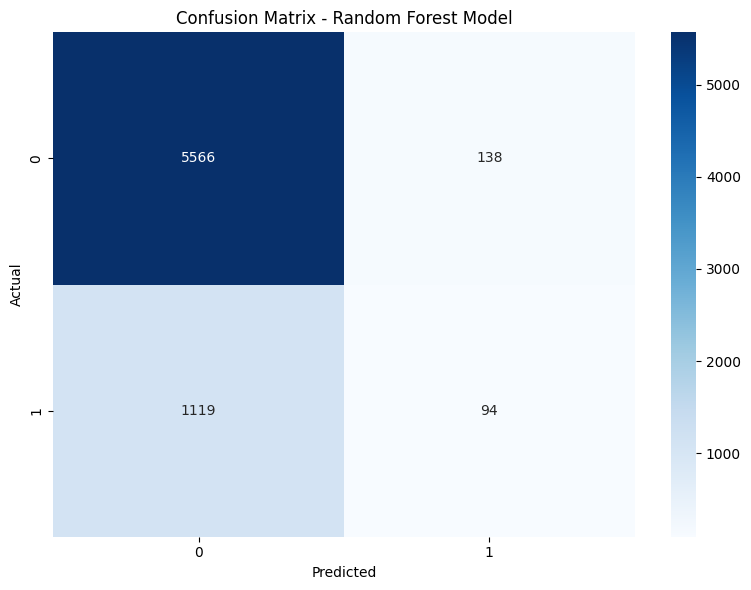

In [15]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


Feature Importances:
                  feature  importance
3  AverageViewingDuration    0.223846
2     ViewingHoursPerWeek    0.217243
0          MonthlyCharges    0.194280
1            TotalCharges    0.192392
4              AccountAge    0.172238


<Figure size 1000x600 with 0 Axes>

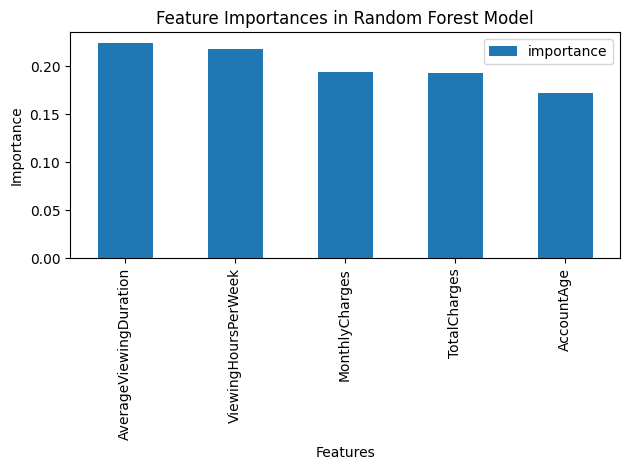

In [16]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance)

# Plot feature importances
plt.figure(figsize=(10, 6))
feature_importance.plot(x='feature', y='importance', kind='bar')
plt.title('Feature Importances in Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

> Results: The model shows mixed results compared to the logistic regression baseline. While there's a slight decrease in overall accuracy (from 0.8261 to 0.8183) and AUC-ROC (from 0.7200 to 0.6647), the model demonstrates improved ability to identify potential churners, as evidenced by the increased recall (from 0.0486 to 0.0775) and F1 score (from 0.0893 to 0.1301) for the churn class. This comes at the cost of lower precision (0.4052 vs 0.5463), indicating more false positives. The trade-off aligns with the goal of identifying more customers for targeted retention efforts, although with reduced accuracy. Both models struggle with class imbalance, but the random forest's improved recall suggests it might be more effective for the specific task of identifying customers for discount offers, despite the slight decrease in overall performance metrics.

<hr>

### G.5 Business Impact from Current Model Performance

In [17]:
from sklearn.metrics import confusion_matrix

def churn_cost_calculation(y_true, y_pred):
    """
    Calculate the cost and benefit of the churn prevention strategy compared to taking no action.

    Parameters:
    y_true (array): True labels (1 for churn, 0 for non-churn)
    y_pred (array): Predicted labels (1 for churn, 0 for non-churn)

    Returns:
    dict: A dictionary containing cost calculations and key metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Constants
    monthly_charge = 12.5  # average monthly charge
    discount_percentage = 0.5  # 50% discount
    discount_duration = 3  # 3 months

    # Scenario 1: Do nothing
    do_nothing_revenue = (tn + fp) * monthly_charge * discount_duration

    # Scenario 2: Apply discount to predicted churners
    discount_revenue = (tn * monthly_charge * discount_duration) + ((tp + fp) * monthly_charge * discount_percentage * discount_duration)

    # Benefit of the strategy
    benefit = discount_revenue - do_nothing_revenue

    return {
        "do_nothing_revenue": round(do_nothing_revenue, 2),
        "discount_revenue": round(discount_revenue, 2),
        "benefit": round(benefit, 2),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    }

# Usage
results = churn_cost_calculation(y_val, y_pred)

print(f"Revenue if do nothing: ${results['do_nothing_revenue']:,.2f}")
print(f"Revenue with discount strategy: ${results['discount_revenue']:,.2f}")
print(f"Benefit of discount strategy: ${results['benefit']:,.2f}")
print(f"True Positives (correctly predicted churners): {results['true_positives']}")
print(f"False Positives (incorrectly predicted churners): {results['false_positives']}")
print(f"False Negatives (missed churners): {results['false_negatives']}")
print(f"True Negatives (correctly predicted non-churners): {results['true_negatives']}")

Revenue if do nothing: $213,900.00
Revenue with discount strategy: $213,075.00
Benefit of discount strategy: $-825.00
True Positives (correctly predicted churners): 94
False Positives (incorrectly predicted churners): 138
False Negatives (missed churners): 1119
True Negatives (correctly predicted non-churners): 5566


> Results: The churn_cost_calculation calculates the cost-benefit of implementing the 50% discount for 3 months to the customers predicted to churn and gives an overview over how the model is performing. This assumes that all churners receiving the discount will remain for the three months. This calculation does not go beyond the three months. It is meant as a "business performance metric". Its impact will be discussed in the project report. In terms of this model, there would only be a 825 loss, however, 1119 churners would not be identified.

<hr>

## H. Experiment Outcomes

final_experiment_outcome = 'Hypothesis Partially Confirmed'

> Key Learnings: The Random Forest model showed potential in improving churn detection, particularly in recall, but struggled with precision and overall accuracy. The high number of false negatives highlights a critical area for improvement, as missed churners represent a substantial potential revenue loss. The current model's performance underscores the challenge of balancing precision and recall in an imbalanced dataset, and the importance of considering the business impact beyond just statistical metrics.

> Recommendations for Next Experiment:  I will try to improve the model's ability to identify potential churners without significantly increasing false positives. I will try another algorithm like Gradient Boosting or XGBoost, which may be better at handling the class imbalance.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0e20096b-eda0-43a0-b83c-e24d084104d6' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>